In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import sklearn.linear_model as lnm
from sklearn.decomposition import PCA
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import pickle
# %matplotlib notebook

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
### load dff
fly_nums=[226,227,228,234,239,240,241,242,249,250]
# dataset_path="/oak/stanford/groups/trc/data/Ilana/2P/data"
scratch_path="/scratch/users/ilanazs"

load_files=[]
for num in fly_nums:
#     fly_directory=os.path.join(dataset_path,f'fly_{num}')
#     load_directory = os.path.join(fly_directory, "dff")
    load_scratch=os.path.join(scratch_path,f'fly_{num}')
    for i in range(2):
        dff_file = f"functional_channel_{i+1}_moco_warp_blurred_hpf_dff.h5"
        final_dir=os.path.join(load_scratch,dff_file)
        load_files.append(final_dir)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
load_files

['/scratch/users/ilanazs/fly_226/functional_channel_1_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_226/functional_channel_2_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_227/functional_channel_1_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_227/functional_channel_2_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_228/functional_channel_1_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_228/functional_channel_2_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_234/functional_channel_1_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_234/functional_channel_2_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_239/functional_channel_1_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_239/functional_channel_2_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_240/functional_channel_1_moco_warp_blurred_hpf_dff.h5',
 '/scratch/users/ilanazs/fly_240/functional_channel_2_moco_warp_b

In [4]:
load_scratch=os.path.join(scratch_path,f'fly_{num}')


In [5]:
# %%time
# avg_fly=[]
# count=0
# for load_file in load_files:
#     if '_2_' in load_file:
# #         print(load_file.split('/')[-3])
#         print(load_file.split('/')[-2])
#         with h5py.File(load_file, 'r') as hf:
#             brain = hf['data'][:]
#             print(f'shape of brain {np.shape(brain)}')
#             if avg_fly==[]:
#                 avg_fly=brain
#                 count+=1
#             else:
#                 avg_fly = avg_fly + brain
#                 count+=1
# print(count)
# avg_fly_final=np.asarray(avg_fly/count)
# del brain
# gc.collect()

In [6]:
# avg_fly_final.shape

In [7]:
test_dir=os.path.join(scratch_path,'test')
if os.path.exists(test_dir)==False:
    os.mkdir(test_dir)
save_test=os.path.join(test_dir, 'test_full_brain_dff.h5')

In [8]:
# with h5py.File(save_test, "w") as data_file:
#     data_file.create_dataset("data", data=avg_fly_final)

In [9]:
%%time
with h5py.File(save_test, 'r') as hf:
    brain = np.nan_to_num(hf['data'])
    brain[np.where(brain==np.max(brain))] = 1
    shape=np.shape(brain)
    print(f'shape of brain {shape}')
    flat_vox=brain.reshape(-1,3384)
    del brain
    gc.collect()
    

shape of brain (314, 146, 91, 3384)
CPU times: user 1min 13s, sys: 1min 23s, total: 2min 36s
Wall time: 2min 36s


In [10]:
pca=PCA()

In [11]:
%%time 
pca_result = pca.fit_transform(flat_vox)
print(np.shape(pca_result))
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"First 5 PCs explain: {cumulative_variance[:5]*100}% of variance")

(4171804, 3384)
First 5 PCs explain: [1.3005996  2.40554543 3.3502457  4.26192516 5.07407439]% of variance
CPU times: user 4h 23min 25s, sys: 1h 24min 19s, total: 5h 47min 44s
Wall time: 15min 44s


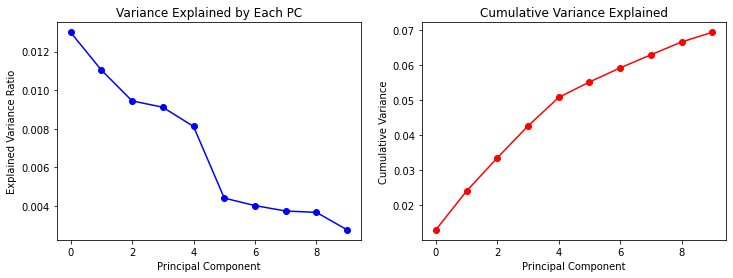

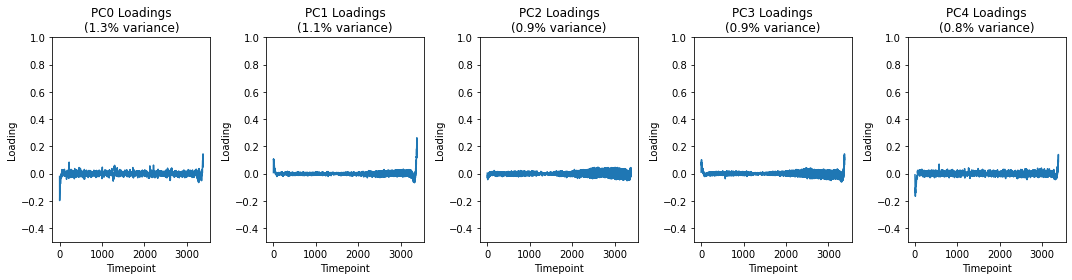

In [12]:
# 1. Plot explained variance
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(explained_variance_ratio[:10], 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Variance Explained by Each PC')

plt.subplot(1, 2, 2)
plt.plot(cumulative_variance[:10], 'ro-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance')
plt.title('Cumulative Variance Explained')
plt.show()

# 2. Examine the principal components (loadings)
# These show which timepoints contribute most to each PC
s,e,b = 0,5,1
plt.figure(figsize=(15, 4))
for i,v in enumerate(np.arange(s,e,b)):
    plt.subplot(1, (e-s), i+1)
    plt.plot(pca.components_[v])
    plt.title(f'PC{v} Loadings\n({explained_variance_ratio[v]*100:.1f}% variance)')
    plt.xlabel('Timepoint')
    plt.ylabel('Loading')
    plt.ylim(-0.5,1)
plt.tight_layout()
plt.show()

In [13]:
np.shape(pca.components_)

(3384, 3384)

In [14]:
count=0
for i in range(np.shape(pca.components_)[0]):
    if np.count_nonzero(pca.components_[i]>0.1)>10:
        print(i)
        count+=1
print(count)

1
1


In [15]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [16]:
shape

(314, 146, 91, 3384)

In [17]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [18]:
np.shape(pca_result.reshape(shape))

(314, 146, 91, 3384)

In [19]:
reshape=pca_result.reshape(shape)
brain=np.moveaxis(reshape,-1,0)
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[4][:,:,::-1]
vmax = 0.5 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

(-0.5, 499.5, 329.5, -0.5)

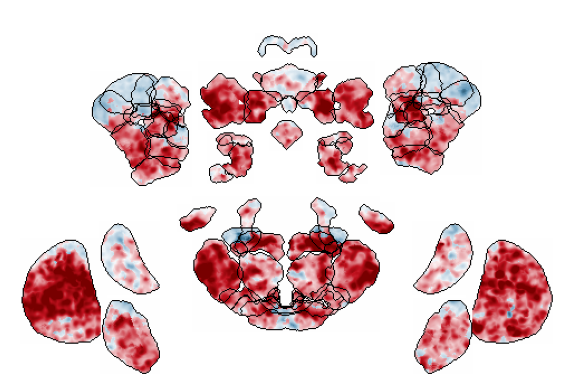

In [20]:
plt.subplots(figsize=(10,10))
plt.imshow(explosion_map[170:,:]) #this was made with cmap=hot
plt.axis('off')